<a href="https://colab.research.google.com/github/Nicolsag/Analise_exploratoria_de_dados_bancarios/blob/main/An%C3%A1lise_explorat%C3%B3ria_de_dados_banc%C3%A1rios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importando as bibliotecas e ajustando o ambiente

<br>

In [5]:
from google.colab import drive
import pandas as pd
from warnings import filterwarnings
filterwarnings('ignore')

In [114]:
from matplotlib import pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

color= 'magma' ##cor utilizada

In [7]:
drive.mount('/content/drive') ## importando o drive

Mounted at /content/drive


------

<br>

## Verificando se o dataset foi importado corretamente

<br>

In [8]:
path = '/content/drive/MyDrive/datasets for training/bank_transactions_data.csv' ## caminho dataset

df = pd.read_csv(path)

In [9]:
df

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40,2024-11-04 08:06:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2507,TX002508,AC00297,856.21,2023-04-26 17:09:36,Credit,Colorado Springs,D000625,21.157.41.17,M072,Branch,33,Doctor,109,1,12690.79,2024-11-04 08:11:29
2508,TX002509,AC00322,251.54,2023-03-22 17:36:48,Debit,Tucson,D000410,49.174.157.140,M029,Branch,48,Doctor,177,1,254.75,2024-11-04 08:11:42
2509,TX002510,AC00095,28.63,2023-08-21 17:08:50,Debit,San Diego,D000095,58.1.27.124,M087,Branch,56,Retired,146,1,3382.91,2024-11-04 08:08:39
2510,TX002511,AC00118,185.97,2023-02-24 16:24:46,Debit,Denver,D000634,21.190.11.223,M041,Online,23,Student,19,1,1776.91,2024-11-04 08:12:22


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2512 entries, 0 to 2511
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2512 non-null   object 
 1   AccountID                2512 non-null   object 
 2   TransactionAmount        2512 non-null   float64
 3   TransactionDate          2512 non-null   object 
 4   TransactionType          2512 non-null   object 
 5   Location                 2512 non-null   object 
 6   DeviceID                 2512 non-null   object 
 7   IP Address               2512 non-null   object 
 8   MerchantID               2512 non-null   object 
 9   Channel                  2512 non-null   object 
 10  CustomerAge              2512 non-null   int64  
 11  CustomerOccupation       2512 non-null   object 
 12  TransactionDuration      2512 non-null   int64  
 13  LoginAttempts            2512 non-null   int64  
 14  AccountBalance          

------

# 1. Qual é a distribuição estatística da coluna TransactionAmount e existem outliers significativos?

<br>

In [129]:
df['TransactionAmount'].describe()

,TransactionAmount
count,2512.000000
mean,297.593778
std,291.946243
min,0.260000
25%,81.885000
50%,211.140000
75%,414.527500
max,1919.110000


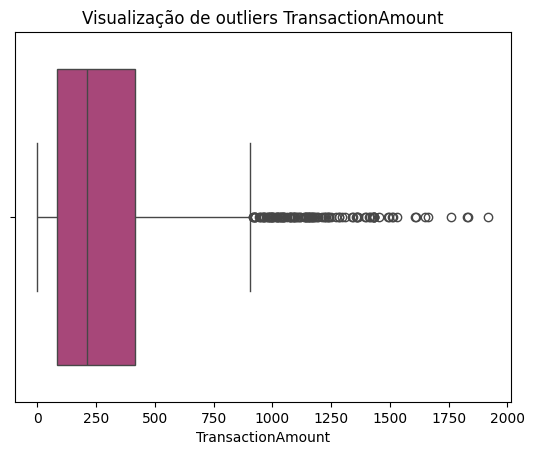

In [126]:
sns.boxplot(
    data=df,
    x='TransactionAmount',
    palette=(color)
)

plt.title('Visualização de outliers TransactionAmount')
plt.xlabel('TransactionAmount')
plt.show()

### A distribuição estatística é:

|TransactionAmount| |
|-|-|
|count |	2512.00|
|mean |	297.59|
|std |	291.94|
|min |	0.26|
|25% |	81.88|
|50% |	211.14|
|75% |	414.52|
|max |	1919.11|

## Já outliers são presentes em `TransactionAmount`.

a distribuição de dados está entre 0 e 825, de 826 até +~ 1900 outliers.

deve-se observar uma grande concentração de dados entre 826 e 1500, devendo-se considerar se são de fato outliers. Acima disso, deixa de se tornar padrão.

<br>

-----------

## 2. Quais são os canais (Channel) mais frequentes para cada tipo de transação (TransactionType)?

Text(0, 0.5, 'Frequência')

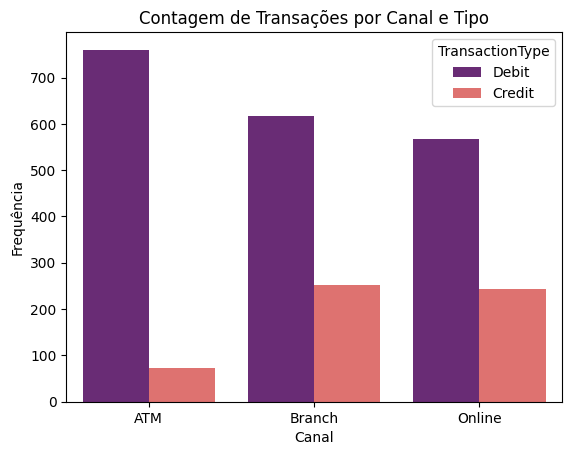

In [131]:
sns.countplot(
    data=df,
    x='Channel',
    hue='TransactionType',
    palette=color
)

plt.xticks(
    ticks=[0, 1, 2],
    labels=['ATM', 'Branch', 'Online']
)
plt.title('Contagem de Transações por Canal e Tipo')
plt.xlabel('Canal')
plt.ylabel('Frequência')

In [14]:
df.groupby('Channel')['TransactionType'].value_counts()

Channel  TransactionType
ATM      Debit              760
         Credit              73
Branch   Debit              617
         Credit             251
Online   Debit              567
         Credit             244
Name: count, dtype: int64

## Débito.

Mas deve-se observar a frequência, sendo:

 * `ATM`: Maior uso de débito e menor frequência em crédito;

 * `Branch`: Segunda maior frequência em débito e maior frequência em crédito;

 * `Online`: Menor frequência em débito e segunda maior frequência em crédito.

 <br>

---------

## 3. Existe alguma correlação matemática entre a idade do cliente (CustomerAge) e o saldo da conta (AccountBalance)?

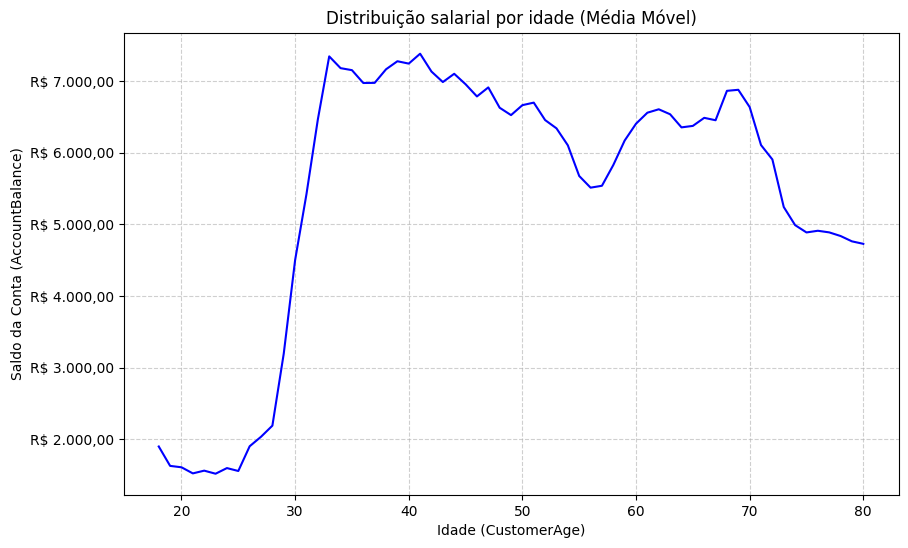

In [128]:
plot_data = df.groupby('CustomerAge')['AccountBalance'].mean().reset_index()
plot_data['Media_Movel'] = plot_data['AccountBalance'].rolling(window=5, min_periods=1).mean()

plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_data, x='CustomerAge', y='Media_Movel', color='b')

plt.grid(True, linestyle='--', alpha=0.6)

formatter = ticker.FuncFormatter(lambda x, pos: f'R$ {x:,.2f}'.replace(',', 'v').replace('.', ',').replace('v', '.'))
plt.gca().yaxis.set_major_formatter(formatter)

plt.title('Distribuição salarial por idade (Média Móvel)')
plt.xlabel('Idade (CustomerAge)')
plt.ylabel('Saldo da Conta (AccountBalance)')

plt.show()

In [118]:
df_age = pd.cut(
    df['CustomerAge'],
    bins=[18, 26, 40, 60, 120],
    labels=["Young", "Young Adult", "Adult", "Eldery"],
    right=False
)

df.groupby('Custom_CustomerAge')['AccountBalance'].describe()

,count,mean,std,min,25%,50%,75%,max
Custom_CustomerAge,,,,,,,,
Young,475.0,1560.955074,1875.516891,102.20,608.905,1071.04,1616.000,9963.39
Young Adult,607.0,5352.875750,4058.534898,101.25,1381.515,5397.68,8616.605,14977.99
Adult,819.0,6339.738877,3787.857923,120.89,3118.745,6215.96,8627.705,14942.78
Eldery,611.0,5997.109116,3408.508558,207.10,3475.530,5692.31,7577.935,14904.90


## Sim, existe uma correlação clara.

* clientes mais novos tendem a ter menos saldo bancário;

* entre os 27 e 35, o saldo costuma a crescer exponencialmente;

* Em idades mais avançadas, o saldo persiste com maior consistência e tende a ter uma queda maior a partir dos 68, isso pode acontecer por fatores como a decisão de "Aproveitar a vida" pós aposentadoria.

<br>

## A média por faixa etária é:

<br>

|Custom_CustomerAge|mean|
|-|-|
|Young (18, 25) | 1560.95|
|Young Adult (26, 39) | 352.87|
|Adult (40, 59) | 6339.73|
|Eldery (60, 120) |	5997.10|

<br>

-----------

## 4. Como o volume financeiro total de transações varia de acordo com a localização (Location)?


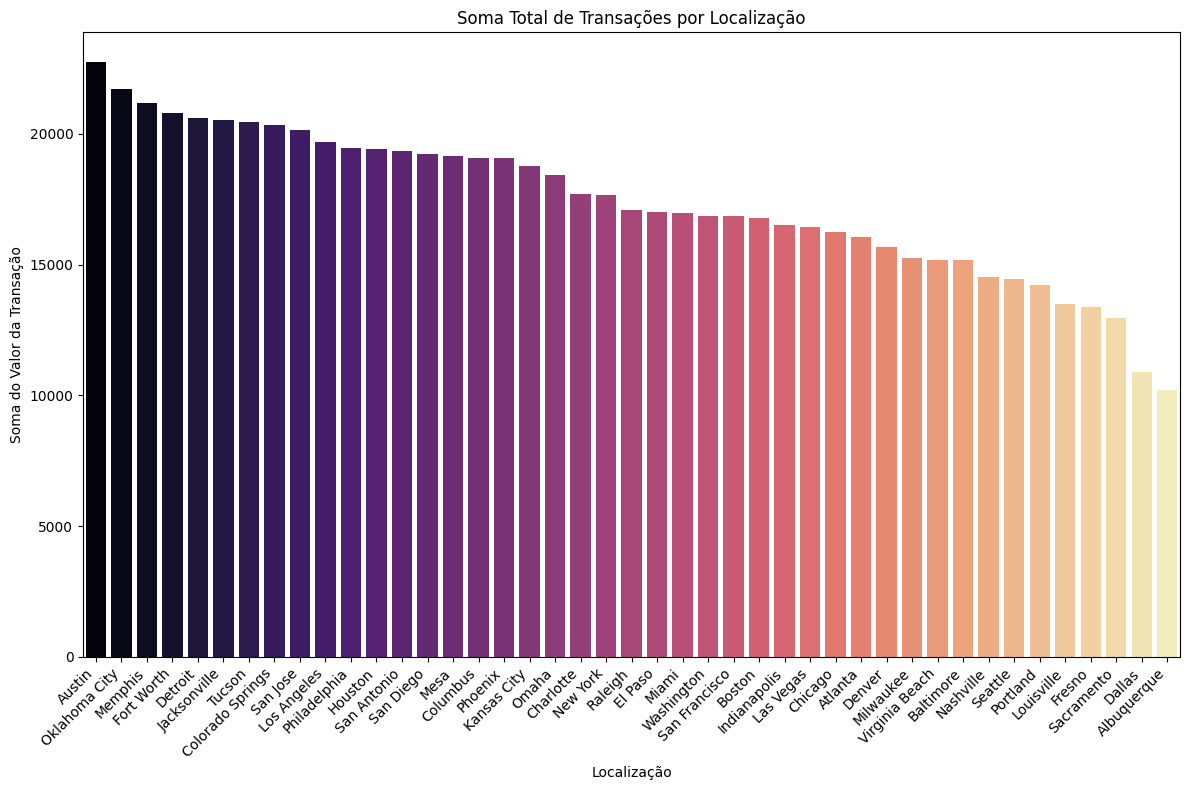

In [115]:
df_Location_TransactionAmount = df.groupby('Location')['TransactionAmount'].agg(['sum', 'mean', 'count']).sort_values(by='sum', ascending=False)

plt.figure(figsize=(12, 8))

sns.barplot(
    data=df_Location_TransactionAmount.reset_index(),
    x='Location',
    y='sum',
    palette=color
)

plt.title('Soma Total de Transações por Localização')
plt.xlabel('Localização')
plt.ylabel('Soma do Valor da Transação')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
df_Location_TransactionAmount

,sum,mean,count
Location,,,
Austin,22740.90,385.438983,59
Oklahoma City,21716.04,319.353529,68
Memphis,21170.53,336.040159,63
Fort Worth,20776.74,296.810571,70
Detroit,20609.76,327.139048,63
Jacksonville,20519.47,341.991167,60
Tucson,20459.76,305.369552,67
Colorado Springs,20344.63,339.077167,60
San Jose,20127.87,341.150339,59


# As cidades como:
* Austin;
* Oklahoma City;
* Memphis;
* Fort Worth;
* Detroit.

Possuem maior maiores índices de transações.

<br>

# E as cidades:
* Louisville;
* Fresno;
* Sacramento;
* Dallas;
* Albuquerque.

Possuem menores índices de transações.

<br>


-------

## 5. Qual é o tempo médio decorrido entre a transação atual (TransactionDate) e a anterior (PreviousTransactionDate) para cada conta (AccountID)?

In [20]:
df['TransactionDate'] = pd.to_datetime(df['TransactionDate'])
df['PreviousTransactionDate']= pd.to_datetime(df['PreviousTransactionDate'])

df = df.sort_values(['AccountID', 'TransactionDate'])

df['time_diff'] = df.groupby('AccountID')['TransactionDate'].diff()

mean_by_account = df.groupby('AccountID')['time_diff'].mean()

mean_by_account

,time_diff
AccountID,
AC00001,59 days 23:56:14
AC00002,57 days 12:10:03
AC00003,68 days 06:33:03.500000
AC00004,30 days 14:49:04.875000
AC00005,35 days 15:12:55.125000
...,...
AC00496,50 days 00:49:14.500000
AC00497,58 days 14:36:27.800000
AC00498,49 days 00:04:06.285714285


## A média de cada valor individual diário pode ser vista pela tabela acima com maior precisão.

<br>

-----

## 6. As transações associadas a um número alto de tentativas de login (LoginAttempts) apresentam valores (TransactionAmount) acima da média global?

In [68]:
df['TransactionAmount'].mean().round(2)

np.float64(297.59)

In [73]:
df.groupby('LoginAttempts')['TransactionAmount'].agg(['mean', 'count']).sort_values(by='mean', ascending=False)

,mean,count
LoginAttempts,,
2,334.077778,27
5,308.961875,32
1,298.027054,2390
3,265.923871,31
4,253.762188,32


## Sim,

5 tentativas de logins tem média de 308.96, enquando a média global é de 297.59. Vale-se destacar que 2 tentativas é a maior média, sendo de 334.07, mas se considerando normal comparado à 5.

Abaixo de 4, a média já se mantém abaixo do global, sendo 253.76.

<br>

-------

## 7. Quais são as ocupações de clientes (CustomerOccupation) que possuem o maior ticket médio por transação?

In [76]:
df.groupby('CustomerOccupation')['TransactionAmount'].mean().sort_values(ascending=False)

,TransactionAmount
CustomerOccupation,
Student,313.220746
Retired,294.533673
Doctor,292.700174
Engineer,289.040096


## Estas são:

|CustomerOccupation|Transação média|
|-|-|
|Student |	313.22|
|Retired |	294.53|
|Doctor |	292.70|
|Engineer |	289.04|

<br>

Sendo `estudante` o maior ticket médio por transação, sendo seguidos por `aposentado`, `doutor` e `engenheiro`.

<br>

---------------

## 8. Existe alguma relação identificável entre a duração da transação (TransactionDuration) e o canal utilizado (Channel)?

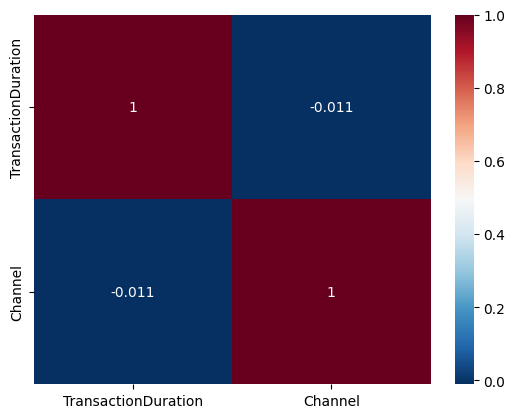

In [101]:
df['Channel'] = df['Channel'].astype('category').cat.codes

sns.heatmap(df[['TransactionDuration', 'Channel']].corr(), annot=True, cmap='RdBu_r')
plt.show()

## Não,

Não existe correlação significativa, sendo esta de -0.011, como representada no gráfico de correlação acima.

<br>

------

## 9. Qual é o top 5 de comerciantes (MerchantID) responsáveis pelo maior volume total de dinheiro transacionado?

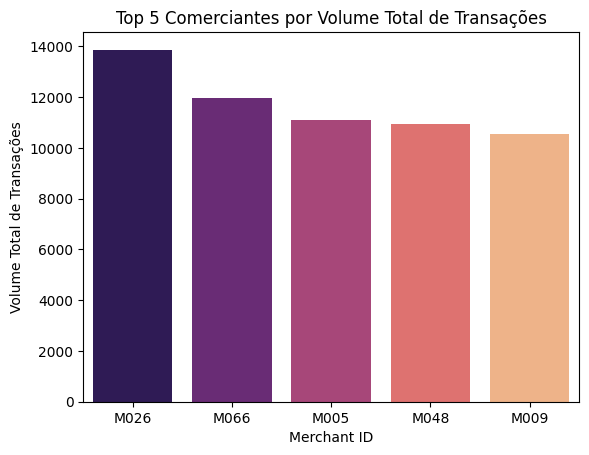

In [116]:
plot_data = df.groupby('MerchantID')['TransactionAmount'].sum().sort_values(ascending=False).head(5).reset_index()
sns.barplot(
    data=plot_data,
    x='MerchantID',
    y='TransactionAmount',
    palette=color
)

plt.title('Top 5 Comerciantes por Volume Total de Transações')
plt.xlabel('Merchant ID')
plt.ylabel('Volume Total de Transações')
plt.show()

In [117]:
df.groupby('MerchantID')['TransactionAmount'].sum().sort_values(ascending=False).head(5).reset_index()

,MerchantID,TransactionAmount
0,M026,13865.15
1,M066,11948.75
2,M005,11099.93
3,M048,10954.79
4,M009,10526.04


## O top 5 são:

Top|Comerciantes|Volume total Transações|
-|-|-|
1 |M026 |	13865.15|
2 |M066 |	11948.75|
3 |M005 |	11099.93|
4 |M048 |	10954.79|
5 |M009 |	10526.04|

<br>

-----------

## 10. Como se comporta a proporção de cada TransactionType quando analisamos diferentes grupos ou faixas etárias criadas a partir de CustomerAge?

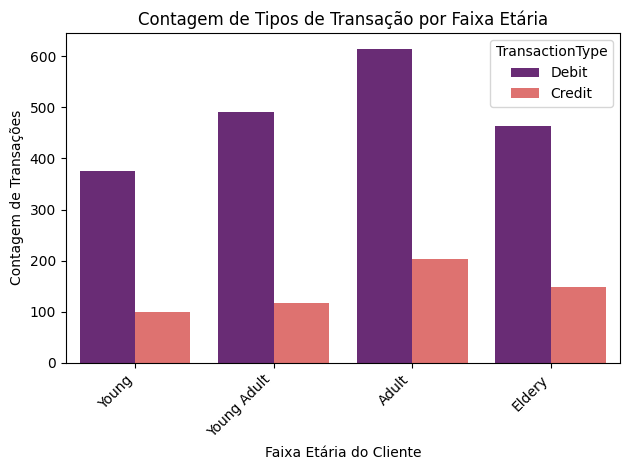

In [124]:
sns.countplot(
    data=df,
    x='Custom_CustomerAge',
    hue='TransactionType',
    palette=color
)

plt.title('Contagem de Tipos de Transação por Faixa Etária')
plt.xlabel('Faixa Etária do Cliente')
plt.ylabel('Contagem de Transações')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [136]:
df.groupby('Custom_CustomerAge')['TransactionType'].value_counts()

Custom_CustomerAge  TransactionType
Young               Debit              376
                    Credit              99
Young Adult         Debit              490
                    Credit             117
Adult               Debit              615
                    Credit             204
Eldery              Debit              463
                    Credit             148
Name: count, dtype: int64

## As transações tem as seguintes proporções:

<br>

OBS: Vale-se ressaltar que, todos majoritariamente gastam mais com débito do que crédito.

<br>

### Jovens:
* Entre todos, menor gasto em débito;
* Também o menor gasto em crédito.

## Jovens adultos:
* Segundo maior gasto em débito;
* Penúltimo menor gasto em crédito.

## Adultos:
* O maior gasto em débito de todos entre estes;
* Também o maior gasto em crédito.

## Idosos:
* Penúltimo menor gasto em débito;
* Segundo maior gasto em crédito.

<br>